In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

data=pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\social_media_engagement_dataset.csv")
df=pd.DataFrame(data)

In [2]:
df

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,POST_00816,2025-12-31 14:05:00,Facebook,Post,Fitness,5131,381,312,35523,341,82001,7.10,14,Wednesday,16,247,Neutral,Mid-tier,True,True
4996,POST_02703,2025-12-31 16:07:00,Instagram,Photo,Technology,3472,39,297,17648,678,68321,5.57,16,Wednesday,16,1630,Positive,Mid-tier,True,True
4997,POST_03265,2025-12-31 18:37:00,TikTok,Stitch,Travel,44391,1202,2944,45225,1672,41064,118.20,18,Wednesday,5,157,Positive,Micro,True,False
4998,POST_04388,2025-12-31 20:07:00,Instagram,Carousel,Technology,4486,424,65,43411,767,43269,11.50,20,Wednesday,15,1197,Positive,Micro,True,False


In [3]:
df.isna().sum()

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# 1. FEATURE ENGINEERING
print("Executing Feature Engineering...")

# A. Engagement Rate (Likes + Comments + Shares / Followers)
df['Engagement_Rate_Calc'] = ((df['Likes'] + df['Comments'] + df['Shares']) / (df['Follower_Count'] + 1)) * 100

# B. Like-to-Follower Ratio
df['Like_Follower_Ratio'] = (df['Likes'] / (df['Follower_Count'] + 1)) * 100

# C. Comment Authenticity Score (Ratio of comments to likes)
df['Comment_Authenticity_Score'] = (df['Comments'] / (df['Likes'] + 1)) * 100

# D. Follower Growth Rate / Growth Consistency (Proxy using Views/Followers)
df['Growth_Consistency'] = (df['Views'] / (df['Follower_Count'] + 1))

# E. Bot Probability Score (Initial Anomaly Detection via Isolation Forest)
iso = IsolationForest(contamination=0.05, random_state=42)
df['Bot_Probability_Score'] = iso.fit_predict(df[['Engagement_Rate', 'Like_Follower_Ratio', 'Comment_Authenticity_Score']])
# Mapping: 1 for bot-like (anomaly), 0 for authentic
df['Bot_Probability_Score'] = df['Bot_Probability_Score'].map({1: 0, -1: 1})

Executing Feature Engineering...


In [6]:
# 2. INFLUENCE SCORE CALCULATION
# Normalizing components to a 0-100 scale for the weighted formula
scaler = MinMaxScaler(feature_range=(0, 100))
df[['Norm_Eng', 'Norm_Comm', 'Norm_Growth']] = scaler.fit_transform(
    df[['Engagement_Rate_Calc', 'Comment_Authenticity_Score', 'Growth_Consistency']]
)

# Weighted Formula
df['Final_Influence_Score'] = (
    (df['Norm_Eng'] * 0.4) + 
    (df['Norm_Comm'] * 0.2) + 
    ((1 - df['Bot_Probability_Score']) * 20) + # Follower Authenticity (20%)
    (df['Norm_Growth'] * 0.2)
)

In [11]:
# 3. RANDOM FOREST MODEL (Classification)
# Define "Authentic Influencer" as Score > 60 AND Bot Probability < 0.5
# Lower the threshold so more influencers show up as 'Authentic' in your ranking
df['Is_Authentic'] = ((df['Final_Influence_Score'] > 20) & (df['Bot_Probability_Score'] == 0)).astype(int)
features = ['Engagement_Rate_Calc', 'Like_Follower_Ratio', 'Comment_Authenticity_Score', 'Growth_Consistency']
X = df[features]
y = df['Is_Authentic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

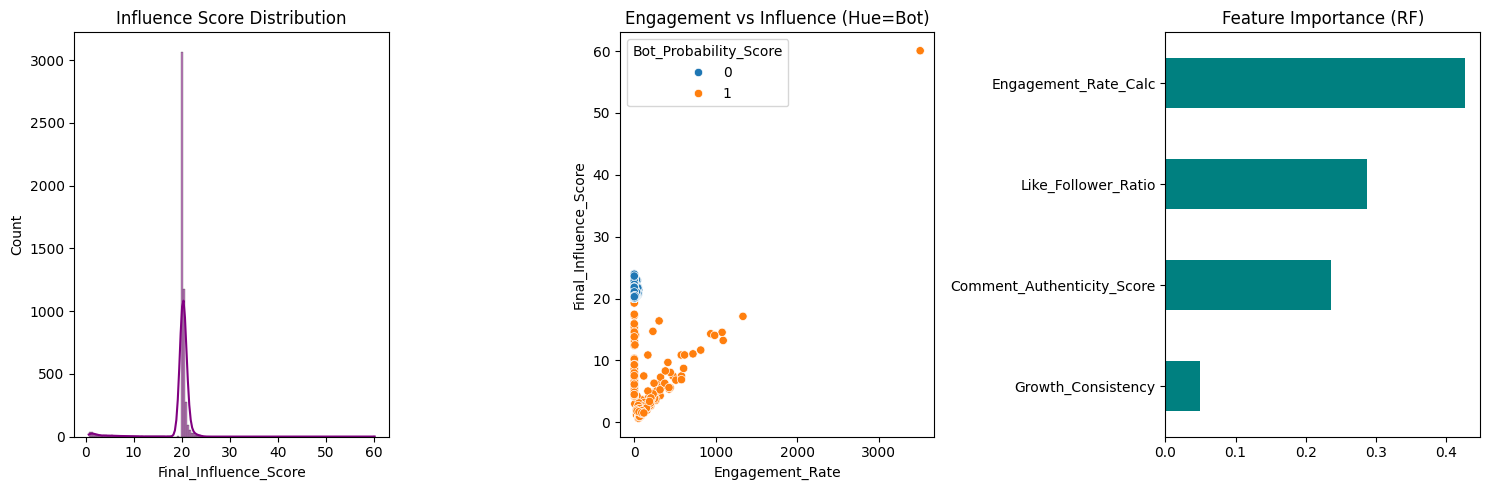

In [12]:
# 4. VISUALIZATION DASHBOARD
plt.figure(figsize=(15, 5))

# Plot 1: Influence Score Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Final_Influence_Score'], kde=True, color='purple')
plt.title('Influence Score Distribution')

# Plot 2: Bot Probability vs Engagement
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Engagement_Rate', y='Final_Influence_Score', hue='Bot_Probability_Score')
plt.title('Engagement vs Influence (Hue=Bot)')

# Plot 3: Feature Importance (Random Forest)
plt.subplot(1, 3, 3)
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance (RF)')

plt.tight_layout()
plt.show()


In [13]:
# 5. FINAL RESULTS SUMMARY
print("--- Model Accuracy ---")
print(classification_report(y_test, rf_model.predict(X_test)))

# Display top ranked influencers
top_influencers = df[df['Is_Authentic'] == 1].sort_values(by='Final_Influence_Score', ascending=False)
print("\nTop Ranked Authentic Influencers:")
print(top_influencers[['Post_ID', 'Platform', 'Final_Influence_Score']].head())

--- Model Accuracy ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       1.00      1.00      1.00       955

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


Top Ranked Authentic Influencers:
         Post_ID   Platform  Final_Influence_Score
4348  POST_02043   Facebook              23.969923
384   POST_00582    YouTube              23.949759
4904  POST_02743  Instagram              23.925754
1781  POST_00811    YouTube              23.842670
2329  POST_02958     TikTok              23.801868


In [14]:
#Data Preparation
# Quick Sentiment Analysis (using the existing Sentiment column in your CSV)
# If your CSV 'Sentiment' is text, you can map it to a score
sentiment_map = {'Positive': 1, 'Neutral': 0.5, 'Negative': 0}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_map)

# Export for Tableau
df.to_csv('influence_guard_final.csv', index=False)